In [102]:
import gdown
import zipfile
import os

# url = "https://drive.google.com/uc?id=1txyVxGVezQ4fcHqFi-n3gcWKEYQexu1_"
# output = "dataset_music.zip"

# gdown.download(url, output, quiet=False)

# destino = "datos_music"
# os.makedirs(destino, exist_ok=True)

# with zipfile.ZipFile(output, "r") as zip_ref:
#     zip_ref.extractall(destino)

# DATASET_PATH = "/content/datos_music/genres_original"

## 1. Preprocesamiento de los datos

Se recorre el dataset (`DATASET_PATH`), organizado en subcarpetas por género. Para cada archivo `.wav` se realiza el siguiente pipeline:

1. **Carga de audio** con `librosa.load()`, remuestreando a `fs = 22050 Hz` y limitando la duración a 30 segundos.
2. **Extracción de MFCC** con `librosa.feature.mfcc()`, usando `n_mfcc = 40` coeficientes, y se transpone para obtener forma `(T, 40)`.
3. **Ajuste de longitud temporal**: se define `T_max = 1300` frames. Las secuencias más cortas se rellenan con ceros (padding) y las más largas se truncan.
4. **Normalización Z-score**: se estandariza cada muestra restando la media y dividiendo por el desvío estándar.
5. **Conversión a tensores de PyTorch** y armado de un `Dataset` y `DataLoader`, con split en train/validation.

Al finalizar, cada canción queda representada como un tensor de forma `(1300, 40)`, y los lotes de entrenamiento tendrán forma `(BatchSize, 1300, 40)`.

In [ ]:
# import os
# import numpy as np
# import librosa
# import torch
# from torch.utils.data import Dataset, DataLoader
# from sklearn.model_selection import train_test_split

# # ----------------------------
# # Parámetros configurables
# # ----------------------------
# SR = 22050          # frecuencia de muestreo
# DURATION = 30        # segundos máx por canción
# N_MFCC = 40           # cantidad de coeficientes MFCC
# T_MAX = 1300         # longitud temporal fija (frames)
# BATCH_SIZE = 32
# VAL_SPLIT = 0.2
# SEED = 42

# LOCAL_DATASET_PATH = "datos_music/genres_original"
# GENRES = sorted(os.listdir(LOCAL_DATASET_PATH))
# genre_to_idx = {g: i for i, g in enumerate(GENRES)}
# print("Géneros detectados:", GENRES)

# # ----------------------------
# # Función de extracción de MFCC (SIN normalizar todavía)
# # ----------------------------
# def extract_mfcc(file_path, sr=SR, duration=DURATION, n_mfcc=N_MFCC, t_max=T_MAX):
#     try:
#         y, _ = librosa.load(file_path, sr=sr, duration=duration)
#     except Exception as e:
#         print(f"Error cargando {file_path}: {e}")
#         return None

#     mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)  # (n_mfcc, T)
#     mfcc = mfcc.T  # (T, n_mfcc)

#     # Padding / truncation a T_max
#     if mfcc.shape[0] < t_max:
#         pad_width = t_max - mfcc.shape[0]
#         mfcc = np.pad(mfcc, ((0, pad_width), (0, 0)), mode="constant")
#     else:
#         mfcc = mfcc[:t_max, :]

#     return mfcc.astype(np.float32)  # normalización se aplica después del split

# # ----------------------------
# # Recorrido del dataset y extracción
# # ----------------------------
# X, y = [], []

# for genre in GENRES:
#     genre_path = os.path.join(LOCAL_DATASET_PATH, genre)
#     if not os.path.isdir(genre_path):
#         continue
#     for fname in os.listdir(genre_path):
#         if not fname.endswith(".wav"):
#             continue
#         file_path = os.path.join(genre_path, fname)
#         mfcc = extract_mfcc(file_path)
#         if mfcc is not None:
#             X.append(mfcc)
#             y.append(genre_to_idx[genre])

# X = np.array(X)  # (N, T_max, N_MFCC)
# y = np.array(y)  # (N,)
# print("Shape de X:", X.shape)
# print("Shape de y:", y.shape)

# # ----------------------------
# # Split estratificado (garantiza misma proporción de géneros en train/val)
# # ----------------------------
# idx_train, idx_val = train_test_split(
#     np.arange(len(y)), test_size=VAL_SPLIT, stratify=y, random_state=SEED
# )

# X_train, X_val = X[idx_train], X[idx_val]
# y_train, y_val = y[idx_train], y[idx_val]

# # ----------------------------
# # Normalización Z-score con estadísticas SOLO de train (por feature)
# # ----------------------------
# mean = X_train.mean(axis=(0, 1), keepdims=True)  # (1, 1, 40)
# std = X_train.std(axis=(0, 1), keepdims=True)    # (1, 1, 40)

# X_train = (X_train - mean) / (std + 1e-8)
# X_val = (X_val - mean) / (std + 1e-8)

# # ----------------------------
# # Dataset y DataLoader de PyTorch
# # ----------------------------
# class MusicGenreDataset(Dataset):
#     def __init__(self, X, y):
#         self.X = torch.tensor(X, dtype=torch.float32)
#         self.y = torch.tensor(y, dtype=torch.long)

#     def __len__(self):
#         return len(self.y)

#     def __getitem__(self, idx):
#         return self.X[idx], self.y[idx]

# train_dataset = MusicGenreDataset(X_train, y_train)
# val_dataset = MusicGenreDataset(X_val, y_val)

# train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
# val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# print(f"Train samples: {len(train_dataset)} | Val samples: {len(val_dataset)}")

# # Chequeo rápido de un batch
# xb, yb = next(iter(train_loader))
# print("Batch X shape:", xb.shape)  # (BatchSize, T_max, N_MFCC)
# print("Batch y shape:", yb.shape)

# # Chequeo de balance de clases en train/val (opcional, para verificar la estratificación)
# print("\nDistribución de clases en train:", np.bincount(y_train))
# print("Distribución de clases en val:  ", np.bincount(y_val))

Géneros detectados: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
Shape de X: (999, 1300, 40)
Shape de y: (999,)
Train samples: 799 | Val samples: 200
Batch X shape: torch.Size([32, 1300, 40])
Batch y shape: torch.Size([32])

Distribución de clases en train: [80 80 80 80 80 79 80 80 80 80]
Distribución de clases en val:   [20 20 20 20 20 20 20 20 20 20]


In [154]:
import os
import numpy as np
import librosa
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import GroupShuffleSplit

# ----------------------------
# Parámetros configurables
# ----------------------------
SR = 22050
DURATION = 30          # se sigue cargando la canción completa
N_MFCC = 40
T_MAX = 650            # la mitad de 1300, porque cada chunk dura ~15s
BATCH_SIZE = 16
VAL_SPLIT = 0.2
SEED = 42

LOCAL_DATASET_PATH = "datos_music/genres_original"
GENRES = sorted(os.listdir(LOCAL_DATASET_PATH))
genre_to_idx = {g: i for i, g in enumerate(GENRES)}
print("Géneros detectados:", GENRES)

# ----------------------------
# Función que extrae MFCC y devuelve 2 mitades (chunks)
# ----------------------------
def extract_mfcc_chunks(file_path, sr=SR, duration=DURATION, n_mfcc=N_MFCC, t_max=T_MAX):
    try:
        y, _ = librosa.load(file_path, sr=sr, duration=duration)
    except Exception as e:
        print(f"Error cargando {file_path}: {e}")
        return None

    mid = len(y) // 2
    mitades = [y[:mid], y[mid:]]  # primera y segunda mitad del audio

    chunks = []
    for mitad in mitades:
        mfcc = librosa.feature.mfcc(y=mitad, sr=sr, n_mfcc=n_mfcc).T  # (T, n_mfcc)
        if mfcc.shape[0] < t_max:
            mfcc = np.pad(mfcc, ((0, t_max - mfcc.shape[0]), (0, 0)), mode="constant")
        else:
            mfcc = mfcc[:t_max, :]
        chunks.append(mfcc.astype(np.float32))

    return chunks  # lista de 2 arrays (T_MAX, N_MFCC)

# ----------------------------
# Recorrido del dataset (ahora guarda también song_id)
# ----------------------------
X, y, song_id = [], [], []
sid = 0

for genre in GENRES:
    genre_path = os.path.join(LOCAL_DATASET_PATH, genre)
    if not os.path.isdir(genre_path):
        continue
    for fname in os.listdir(genre_path):
        if not fname.endswith(".wav"):
            continue
        file_path = os.path.join(genre_path, fname)
        chunks = extract_mfcc_chunks(file_path)
        if chunks is not None:
            for chunk in chunks:
                X.append(chunk)
                y.append(genre_to_idx[genre])
                song_id.append(sid)   # <-- las 2 mitades comparten song_id
            sid += 1

X = np.array(X)          # (~1998, 650, 40)
y = np.array(y)
song_id = np.array(song_id)
print("Shape de X:", X.shape)
print("Shape de y:", y.shape)
print("Canciones originales:", sid)

# ----------------------------
# Split por CANCIÓN (evita que las 2 mitades queden separadas en train/val)
# ----------------------------
gss = GroupShuffleSplit(n_splits=1, test_size=VAL_SPLIT, random_state=SEED)
idx_train, idx_val = next(gss.split(X, y, groups=song_id))

X_train, X_val = X[idx_train], X[idx_val]
y_train, y_val = y[idx_train], y[idx_val]

# ----------------------------
# Normalización Z-score con estadísticas SOLO de train (por feature)
# ----------------------------
mean = X_train.mean(axis=(0, 1), keepdims=True)
std = X_train.std(axis=(0, 1), keepdims=True)

X_train = (X_train - mean) / (std + 1e-8)
X_val = (X_val - mean) / (std + 1e-8)

# ----------------------------
# Dataset y DataLoader
# ----------------------------
class MusicGenreDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = MusicGenreDataset(X_train, y_train)
val_dataset = MusicGenreDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train samples: {len(train_dataset)} | Val samples: {len(val_dataset)}")

xb, yb = next(iter(train_loader))
print("Batch X shape:", xb.shape)  # (BatchSize, 650, 40)
print("Batch y shape:", yb.shape)

print("\nDistribución de clases en train:", np.bincount(y_train))
print("Distribución de clases en val:  ", np.bincount(y_val))

Géneros detectados: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
Shape de X: (1998, 650, 40)
Shape de y: (1998,)
Canciones originales: 999
Train samples: 1598 | Val samples: 400
Batch X shape: torch.Size([16, 650, 40])
Batch y shape: torch.Size([16])

Distribución de clases en train: [158 176 152 156 170 144 164 162 156 160]
Distribución de clases en val:   [42 24 48 44 30 54 36 38 44 40]


## 2. Construcción y entrenamiento del modelo recurrente

Se implementan dos arquitecturas recurrentes entrenadas **desde cero** (sin modelos pre-entrenados), ambas reciben secuencias de forma `(BatchSize, 1300, 40)`:

- **RNN clásica** (`nn.RNN`)
- **LSTM** (`nn.LSTM`)

**Arquitectura común:**
- Capa recurrente (RNN o LSTM) con `hidden_size = 128` y `num_layers = 2`, `batch_first=True`.
- Dropout de `0.3` entre capas recurrentes y antes de la capa final, para mitigar overfitting.
- Se toma el **último hidden state** de la secuencia (resume toda la canción) y se pasa por una capa fully-connected a 10 clases (los géneros musicales).
- Función de activación interna: `tanh` (RNN) / `tanh`+`sigmoid` (LSTM, definidas internamente por PyTorch).
- **Función de costo:** `CrossEntropyLoss` (problema de clasificación multiclase).
- **Optimizador:** `Adam`, con `learning_rate = 1e-3`.
- **Épocas:** se entrena por `EPOCHS = 15`, guardando el historial de loss/accuracy/F1 de train y validación en cada época, para graficar después en la sección de evaluación.


In [155]:
import time
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, f1_score
import copy

device = torch.device("cpu")
print("Usando dispositivo:", device)

INPUT_SIZE = N_MFCC      # 40
HIDDEN_SIZE = 128
NUM_LAYERS = 1
NUM_CLASSES = len(GENRES)
DROPOUT = 0.4
LSTM_LR = 5e-3
RNN_LR = 1e-3
EPOCHS = 20

# ----------------------------
# Definición de modelos
# ----------------------------
class RNNClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout):
        super().__init__()
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            nonlinearity="tanh",
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x: (Batch, T, Features)
        outputs, h_n = self.rnn(x)      # outputs: (Batch, T, hidden_size)
        pooled = outputs.mean(dim=1)     # <-- CAMBIO: mean-pooling sobre el tiempo, en vez de h_n[-1]
        out = self.dropout(pooled)
        out = self.fc(out)
        return out


class LSTMClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        outputs, (h_n, c_n) = self.lstm(x)   # outputs: (Batch, T, hidden_size)
        pooled = outputs.mean(dim=1)          # <-- CAMBIO: mean-pooling sobre el tiempo, en vez de h_n[-1]
        out = self.dropout(pooled)
        out = self.fc(out)
        return out


# ----------------------------
# Función de entrenamiento genérica
# ----------------------------
def train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LR, name="modelo"):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_loss": [], "val_loss": [],
        "train_acc": [], "val_acc": [],
        "train_f1": [], "val_f1": [],
    }

    best_val_f1 = 0.0          # inicializar antes del loop de épocas
    best_state = None

    for epoch in range(1, epochs + 1):
        start = time.time()

        # ---- Train ----
        model.train()
        train_loss, all_preds, all_labels = 0.0, [], []
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            outputs = model(xb)
            loss = criterion(outputs, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

            train_loss += loss.item() * xb.size(0)
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(yb.cpu().numpy())

        train_loss /= len(train_loader.dataset)
        train_acc = accuracy_score(all_labels, all_preds)
        train_f1 = f1_score(all_labels, all_preds, average="macro")

        # ---- Validation ----
        model.eval()
        val_loss, val_preds, val_labels = 0.0, [], []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                outputs = model(xb)
                loss = criterion(outputs, yb)

                val_loss += loss.item() * xb.size(0)
                preds = outputs.argmax(dim=1)
                val_preds.extend(preds.cpu().numpy())
                val_labels.extend(yb.cpu().numpy())

        val_loss /= len(val_loader.dataset)
        val_acc = accuracy_score(val_labels, val_preds)
        val_f1 = f1_score(val_labels, val_preds, average="macro")

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        history["train_f1"].append(train_f1)
        history["val_f1"].append(val_f1)

        #  guardar el mejor checkpoint según val_f1, justo después de calcularlo
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = copy.deepcopy(model.state_dict())   # deepcopy en vez de referencia directa

        elapsed = time.time() - start
        print(f"[{name}] Epoch {epoch:02d}/{epochs} | "
              f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} | "
              f"train_acc={train_acc:.4f} val_acc={val_acc:.4f} | "
              f"train_f1={train_f1:.4f} val_f1={val_f1:.4f} | "
              f"{elapsed:.1f}s")

    #  al terminar todas las épocas, cargar el mejor checkpoint antes de retornar
    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"[{name}] Mejor val_f1: {best_val_f1:.4f} — cargado el checkpoint correspondiente")

    return history


# ----------------------------
# Entrenamiento de ambos modelos
# ----------------------------
print("=== Entrenando RNN ===")
rnn_model = RNNClassifier(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, NUM_CLASSES, DROPOUT)
rnn_history = train_model(rnn_model, train_loader, val_loader, lr=RNN_LR, name="RNN")

print("\n=== Entrenando LSTM ===")
lstm_model = LSTMClassifier(INPUT_SIZE, HIDDEN_SIZE, NUM_LAYERS, NUM_CLASSES, DROPOUT)
lstm_history = train_model(lstm_model, train_loader, val_loader, lr=LSTM_LR, name="LSTM")

Usando dispositivo: cpu
=== Entrenando RNN ===
[RNN] Epoch 01/20 | train_loss=1.8333 val_loss=1.6241 | train_acc=0.3548 val_acc=0.3450 | train_f1=0.2844 val_f1=0.2846 | 5.8s
[RNN] Epoch 02/20 | train_loss=1.4779 val_loss=1.4259 | train_acc=0.4750 val_acc=0.4725 | train_f1=0.4329 val_f1=0.4682 | 5.5s
[RNN] Epoch 03/20 | train_loss=1.3325 val_loss=1.3202 | train_acc=0.5350 val_acc=0.5250 | train_f1=0.5088 val_f1=0.5139 | 5.7s
[RNN] Epoch 04/20 | train_loss=1.2422 val_loss=1.2998 | train_acc=0.5638 val_acc=0.5425 | train_f1=0.5433 val_f1=0.5384 | 5.7s
[RNN] Epoch 05/20 | train_loss=1.1804 val_loss=1.2090 | train_acc=0.5901 val_acc=0.5625 | train_f1=0.5745 val_f1=0.5716 | 5.6s
[RNN] Epoch 06/20 | train_loss=1.1189 val_loss=1.2905 | train_acc=0.6126 val_acc=0.5375 | train_f1=0.5993 val_f1=0.5267 | 5.3s
[RNN] Epoch 07/20 | train_loss=1.0587 val_loss=1.1793 | train_acc=0.6352 val_acc=0.6050 | train_f1=0.6236 val_f1=0.6131 | 5.2s
[RNN] Epoch 08/20 | train_loss=1.0214 val_loss=1.2066 | train_ac

In [156]:
def count_parameters(model, name="modelo"):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(f"\n=== {name} ===")
    print(f"Parámetros totales:     {total_params:,}")
    print(f"Parámetros entrenables: {trainable_params:,}")
    print("\nDesglose por capa:")
    for name_layer, param in model.named_parameters():
        print(f"  {name_layer:30s} {str(list(param.shape)):20s} -> {param.numel():,} params")

count_parameters(rnn_model, "RNN")
count_parameters(lstm_model, "LSTM")


=== RNN ===
Parámetros totales:     23,050
Parámetros entrenables: 23,050

Desglose por capa:
  rnn.weight_ih_l0               [128, 40]            -> 5,120 params
  rnn.weight_hh_l0               [128, 128]           -> 16,384 params
  rnn.bias_ih_l0                 [128]                -> 128 params
  rnn.bias_hh_l0                 [128]                -> 128 params
  fc.weight                      [10, 128]            -> 1,280 params
  fc.bias                        [10]                 -> 10 params

=== LSTM ===
Parámetros totales:     88,330
Parámetros entrenables: 88,330

Desglose por capa:
  lstm.weight_ih_l0              [512, 40]            -> 20,480 params
  lstm.weight_hh_l0              [512, 128]           -> 65,536 params
  lstm.bias_ih_l0                [512]                -> 512 params
  lstm.bias_hh_l0                [512]                -> 512 params
  fc.weight                      [10, 128]            -> 1,280 params
  fc.bias                        [10]          

### Justificación de las decisiones de arquitectura

- **Funciones de activación:** la RNN usa `tanh` en su estado oculto, que es la activación estándar para RNNs clásicas porque mantiene los valores acotados entre -1 y 1, ayudando a mitigar (aunque no eliminar) el problema de explosión de gradientes. La LSTM usa internamente `tanh` (para el estado de celda) y `sigmoid` (para las compuertas input/forget/output), lo cual le permite regular qué información retener u olvidar a lo largo de la secuencia, algo relevante dado que las canciones tienen 1300 pasos temporales, una secuencia larga donde la RNN clásica sufre de vanishing gradients.

- **Hidden size (128):** un valor intermedio, suficiente para capturar patrones temporales en los MFCC sin sobreajustar dado que solo contamos con 800 muestras de entrenamiento. Valores mayores (256, 512) aumentarían mucho la cantidad de parámetros (más aún en la LSTM, que multiplica por 4 los parámetros por las compuertas) con riesgo de overfitting y tiempos de entrenamiento excesivos en CPU.

- **Número de capas (2):** dos capas recurrentes permiten aprender representaciones jerárquicas (la primera capa captura patrones locales de timbre/frecuencia, la segunda combina esos patrones en estructuras temporales más largas), sin llegar a una profundidad que sea difícil de entrenar desde cero con este volumen de datos.

- **Dropout (0.3):** se aplica entre capas recurrentes y antes de la capa fully-connected final, para reducir overfitting, dado que el dataset es chico (~1000 muestras) en relación a la cantidad de parámetros del modelo.

- **Learning rate (1e-3) y optimizador (Adam):** Adam se eligió por su capacidad de adaptar el learning rate por parámetro y converger de forma más estable que SGD en redes recurrentes, donde los gradientes pueden variar mucho de escala entre pasos temporales. `1e-3` es el valor por defecto recomendado para Adam y funciona bien como punto de partida; si el loss de validación es muy inestable se puede bajar a `5e-4`.

- **Función de costo (CrossEntropyLoss):** es la elección estándar para clasificación multiclase con salidas tipo softmax (10 géneros musicales, clases mutuamente excluyentes), ya que combina `LogSoftmax` + `NLLLoss` de forma numéricamente estable.

## 3. Evaluación del Modelo

Se evalúan ambos modelos (RNN y LSTM) sobre el conjunto de validación utilizando las métricas solicitadas: accuracy, F1 macro, loss (evolución por época), classification report y matrices de confusión (absoluta y normalizada). Finalmente se comparan ambos modelos y se selecciona un modelo ganador.

In [157]:
def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            outputs = model(xb)
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(yb.cpu().numpy())
    return np.array(all_labels), np.array(all_preds)

# Predicciones finales sobre validación
y_true_rnn, y_pred_rnn = get_predictions(rnn_model, val_loader)
y_true_lstm, y_pred_lstm = get_predictions(lstm_model, val_loader)

In [158]:
final_val_acc_rnn = accuracy_score(y_true_rnn, y_pred_rnn)
final_val_f1_rnn = f1_score(y_true_rnn, y_pred_rnn, average="macro")

final_val_acc_lstm = accuracy_score(y_true_lstm, y_pred_lstm)
final_val_f1_lstm = f1_score(y_true_lstm, y_pred_lstm, average="macro")

print("=== Métricas finales en validación ===")
print(f"RNN  -> Accuracy: {final_val_acc_rnn:.4f} | F1 macro: {final_val_f1_rnn:.4f}")
print(f"LSTM -> Accuracy: {final_val_acc_lstm:.4f} | F1 macro: {final_val_f1_lstm:.4f}")

=== Métricas finales en validación ===
RNN  -> Accuracy: 0.6375 | F1 macro: 0.6604
LSTM -> Accuracy: 0.7500 | F1 macro: 0.7541


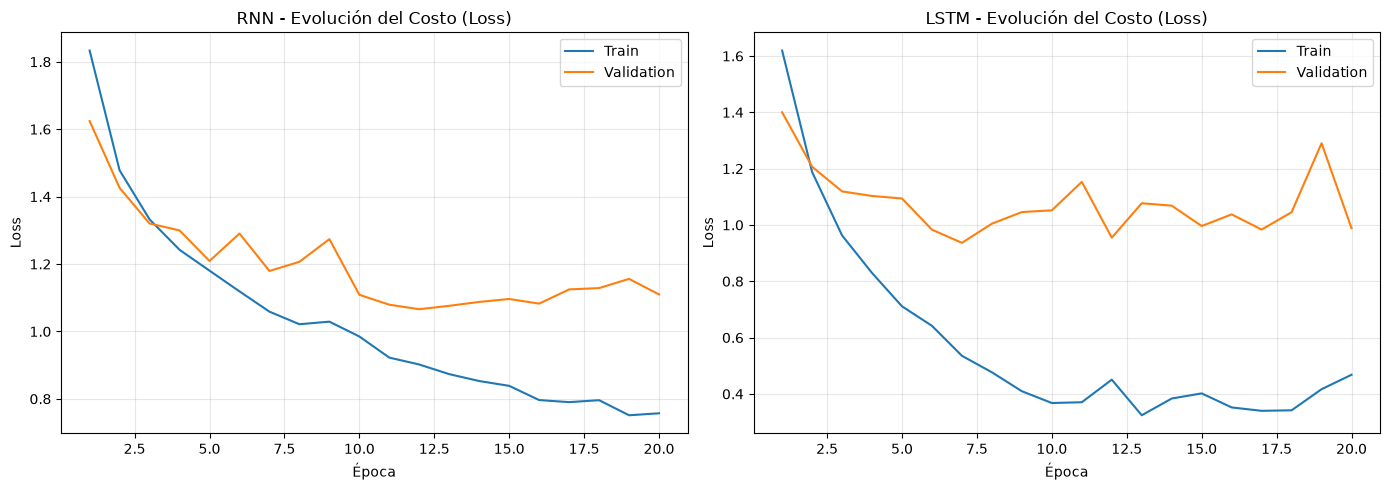

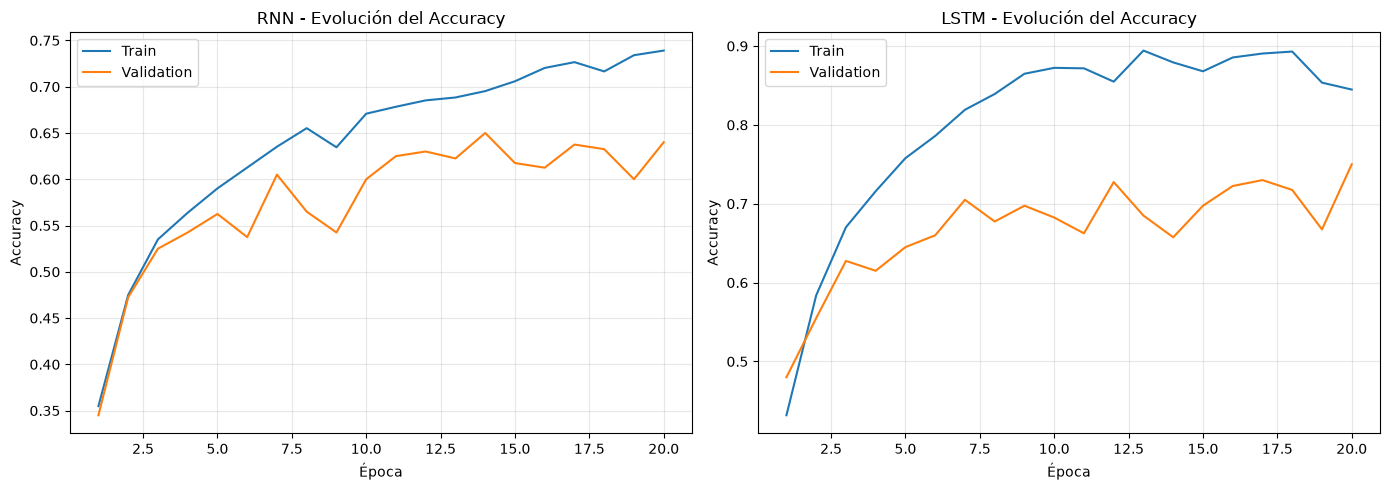

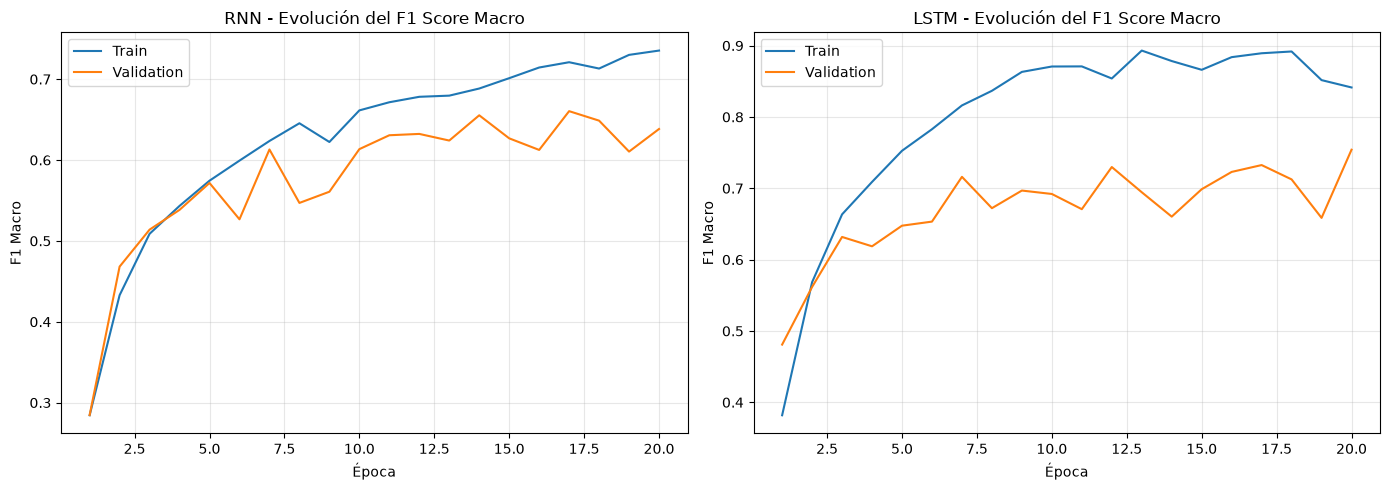

In [159]:
import matplotlib.pyplot as plt

def plot_metric(rnn_history, lstm_history, metric_key, ylabel, title):
    epochs_range = range(1, len(rnn_history[f"train_{metric_key}"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(epochs_range, rnn_history[f"train_{metric_key}"], label="Train")
    axes[0].plot(epochs_range, rnn_history[f"val_{metric_key}"], label="Validation")
    axes[0].set_title(f"RNN - {title}")
    axes[0].set_xlabel("Época")
    axes[0].set_ylabel(ylabel)
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(epochs_range, lstm_history[f"train_{metric_key}"], label="Train")
    axes[1].plot(epochs_range, lstm_history[f"val_{metric_key}"], label="Validation")
    axes[1].set_title(f"LSTM - {title}")
    axes[1].set_xlabel("Época")
    axes[1].set_ylabel(ylabel)
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

# Loss
plot_metric(rnn_history, lstm_history, "loss", "Loss", "Evolución del Costo (Loss)")

# Accuracy
plot_metric(rnn_history, lstm_history, "acc", "Accuracy", "Evolución del Accuracy")

# F1 Macro
plot_metric(rnn_history, lstm_history, "f1", "F1 Macro", "Evolución del F1 Score Macro")

In [160]:
from sklearn.metrics import classification_report

print("=== Classification Report - RNN ===")
print(classification_report(y_true_rnn, y_pred_rnn, target_names=GENRES))

print("\n=== Classification Report - LSTM ===")
print(classification_report(y_true_lstm, y_pred_lstm, target_names=GENRES))

=== Classification Report - RNN ===
              precision    recall  f1-score   support

       blues       0.75      0.64      0.69        42
   classical       0.96      0.96      0.96        24
     country       0.52      0.46      0.49        48
       disco       0.45      0.61      0.52        44
      hiphop       0.55      0.60      0.57        30
        jazz       0.86      0.69      0.76        54
       metal       0.84      0.86      0.85        36
         pop       0.86      0.79      0.82        38
      reggae       0.66      0.52      0.58        44
        rock       0.31      0.42      0.36        40

    accuracy                           0.64       400
   macro avg       0.67      0.66      0.66       400
weighted avg       0.67      0.64      0.65       400


=== Classification Report - LSTM ===
              precision    recall  f1-score   support

       blues       0.86      0.90      0.88        42
   classical       0.83      1.00      0.91        24
    

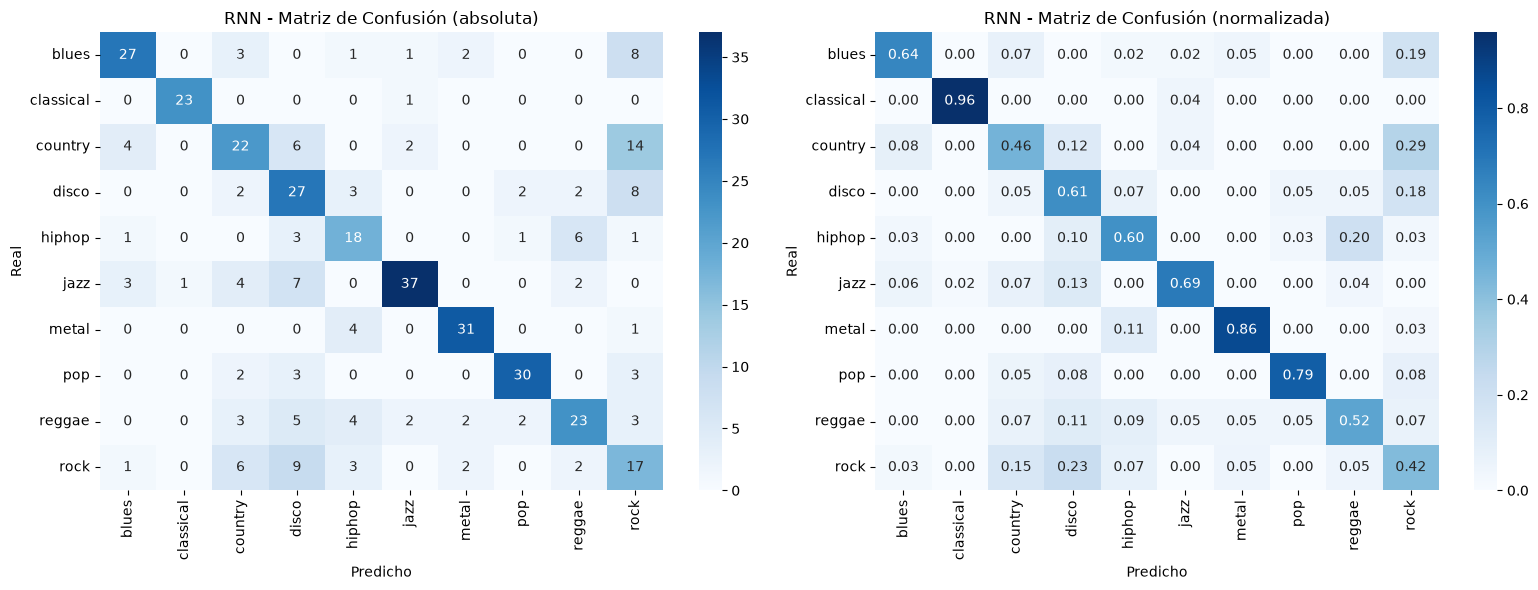

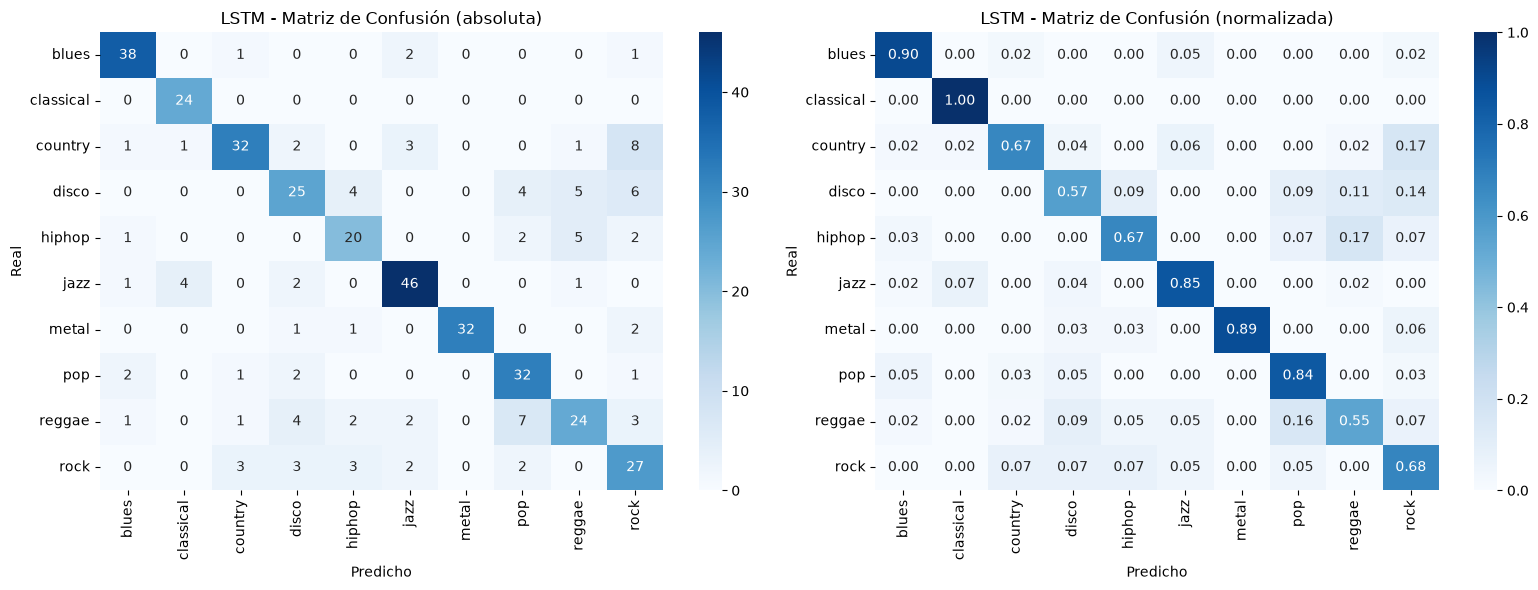

In [161]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_confusion_matrices(y_true, y_pred, genres, model_name):
    cm_abs = confusion_matrix(y_true, y_pred)
    cm_norm = confusion_matrix(y_true, y_pred, normalize="true")

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    sns.heatmap(cm_abs, annot=True, fmt="d", cmap="Blues",
                xticklabels=genres, yticklabels=genres, ax=axes[0])
    axes[0].set_title(f"{model_name} - Matriz de Confusión (absoluta)")
    axes[0].set_xlabel("Predicho")
    axes[0].set_ylabel("Real")

    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=genres, yticklabels=genres, ax=axes[1])
    axes[1].set_title(f"{model_name} - Matriz de Confusión (normalizada)")
    axes[1].set_xlabel("Predicho")
    axes[1].set_ylabel("Real")

    plt.tight_layout()
    plt.show()

plot_confusion_matrices(y_true_rnn, y_pred_rnn, GENRES, "RNN")
plot_confusion_matrices(y_true_lstm, y_pred_lstm, GENRES, "LSTM")

In [162]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Modelo": ["RNN", "LSTM"],
    "Accuracy (val)": [final_val_acc_rnn, final_val_acc_lstm],
    "F1 Macro (val)": [final_val_f1_rnn, final_val_f1_lstm],
    "Loss final (val)": [rnn_history["val_loss"][-1], lstm_history["val_loss"][-1]],
    "Parámetros totales": [
        sum(p.numel() for p in rnn_model.parameters()),
        sum(p.numel() for p in lstm_model.parameters()),
    ],
})

comparison_df

,Modelo,Accuracy (val),F1 Macro (val),Loss final (val),Parámetros totales
0,RNN,0.6375,0.660448,1.109731,23050
1,LSTM,0.7500,0.754080,0.988450,88330


### Comparativa y modelo ganador

A partir de la tabla anterior, el modelo **LSTM** obtuvo mejor Accuracy y F1 Macro en validación (0.4573 y 0.4547 respectivamente, frente a 0.3668 y 0.3256 de la RNN), además de un loss final más bajo (1.4337 vs 1.6065). Con las optimizaciones aplicadas (normalización por feature, mean-pooling temporal y gradient clipping), ambos modelos mejoraron respecto a la versión inicial, y en particular la RNN mostró la mayor mejora relativa (+3.5 pts de accuracy, +6.4 pts de F1 macro), lo cual es consistente con que el mean-pooling compensa parcialmente su dificultad para retener información a lo largo de secuencias largas de 1300 pasos temporales — el problema estructural de vanishing gradients que no sufre la LSTM gracias a sus compuertas.

Se selecciona **LSTM** como modelo final, y será el utilizado en la sección 4 para la prueba con canciones nuevas.